# COMPLETE NAIVE BAYES CLASSIFIER - END TO END

## From Understanding Theory to Production Implementation

This notebook teaches you:
- What is Naive Bayes and how it works
- Bayes Theorem fundamentals
- Three types of Naive Bayes:
  1. Gaussian Naive Bayes (for continuous data)
  2. Multinomial Naive Bayes (for text/count data)
  3. Bernoulli Naive Bayes (for binary features)
- Loading and exploring dataset (EDA)
- Data preprocessing
- Training multiple Naive Bayes variants
- Evaluation and comparison
- Visualizations
- Comparing with other classifiers

### Dataset: Breast Cancer (Built-in from sklearn)
### Problem: Binary Classification (Cancer/No Cancer)
### Total: 569 patients, 30 medical features

Execute cells in order for best learning experience.

---

## INTRODUCTION: WHAT IS NAIVE BAYES?

### Definition

Naive Bayes is a probabilistic classifier based on Bayes Theorem with a strong independence assumption.

### Why "Naive"?

The word "Naive" refers to the assumption that all features are independent of each other.
This assumption is usually NOT true in real data, but surprisingly, the model still works well!

### Bayes Theorem

Mathematical foundation:

P(Class | Features) = P(Features | Class) * P(Class) / P(Features)

Where:
- P(Class | Features) = Posterior probability (what we want to find)
- P(Features | Class) = Likelihood (probability of features given class)
- P(Class) = Prior probability (probability of class)
- P(Features) = Evidence (probability of features)

### Simple Example

Patient has symptom X. What is probability they have cancer?

P(Cancer | Symptom) = P(Symptom | Cancer) * P(Cancer) / P(Symptom)

This is exactly what Naive Bayes calculates!

### Advantages

- Very fast training
- Works well with high-dimensional data
- Requires small training dataset
- Probabilistic predictions (confidence scores)
- Interpretable (can see feature contributions)
- Works surprisingly well despite naive assumption

### Disadvantages

- Independence assumption rarely true
- Zero frequency problem (seen in some implementations)
- Not suitable when features are highly correlated
- Usually not the best performer (but fast!)

### When to Use

- Text classification (emails, documents)
- Spam detection
- Sentiment analysis
- Fast baseline model
- Real-time systems (fast prediction)
- When you have small training data

---

## THREE TYPES OF NAIVE BAYES

### 1. Gaussian Naive Bayes

Assumes features follow a normal (Gaussian) distribution.

Best for:
- Continuous numerical data
- Real-valued features
- Our medical dataset (measurements)

Uses probability density function (PDF) of normal distribution.

### 2. Multinomial Naive Bayes

Assumes features represent counts or frequencies.

Best for:
- Text classification (word counts)
- Document analysis (term frequencies)
- Count data

Often used with TF-IDF (Term Frequency-Inverse Document Frequency).

### 3. Bernoulli Naive Bayes

Assumes features are binary (0 or 1).

Best for:
- Binary features
- Presence/absence data
- Text (word presence, not frequency)

Models P(feature | class) directly.

---

## STEP 0: IMPORT ALL REQUIRED LIBRARIES

In [1]:
# Import data manipulation libraries
import pandas as pd  # For working with tabular data
import numpy as np   # For numerical computations

# Import visualization libraries
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns  # For better looking statistical visualizations
import warnings  # To suppress warning messages
warnings.filterwarnings('ignore')

# Set plot style for better looking charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Data manipulation and visualization libraries imported successfully!')

Data manipulation and visualization libraries imported successfully!


In [2]:
# Import dataset from sklearn
from sklearn.datasets import load_breast_cancer  # Load the breast cancer dataset

# Import data preprocessing tools
from sklearn.model_selection import train_test_split  # Split data into train and test
from sklearn.preprocessing import StandardScaler  # Normalize/scale features

# Import performance evaluation metrics
from sklearn.metrics import (
    accuracy_score,          # How many predictions are correct
    precision_score,         # Of positive predictions, how many are actually positive
    recall_score,            # Of actual positives, how many did we catch
    f1_score,                # Harmonic mean of precision and recall
    confusion_matrix,        # Matrix showing correct and incorrect predictions
    classification_report,   # Detailed report of all metrics
    roc_auc_score,          # Area under the ROC curve
    roc_curve,              # Receiver operating characteristic curve
    log_loss                # Logarithmic loss (for probability predictions)
)

print('Dataset loading and preprocessing tools imported successfully!')

Dataset loading and preprocessing tools imported successfully!


In [3]:
# Import Naive Bayes classifiers
from sklearn.naive_bayes import (
    GaussianNB,        # For continuous data (normal distribution)
    MultinomialNB,     # For count data (text classification)
    BernoulliNB        # For binary features
)

# Import other classifiers for comparison
from sklearn.tree import DecisionTreeClassifier  # For comparison
from sklearn.ensemble import RandomForestClassifier  # For comparison
from sklearn.linear_model import LogisticRegression  # For comparison

print('Naive Bayes and comparison classifiers imported successfully!')

Naive Bayes and comparison classifiers imported successfully!


---

## STEP 1: LOAD AND EXPLORE THE DATASET (EDA)

In [4]:
# Load the breast cancer dataset
dataset = load_breast_cancer()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)  # Features
y = pd.Series(dataset.target, name='target')  # Target (0=Malignant, 1=Benign)

print('='*80)
print('STEP 1: LOADING AND EXPLORING THE DATASET')
print('='*80)
print('\nDATASET BASIC INFORMATION:')
print(f'   Total samples: {X.shape[0]} (patients)')
print(f'   Total features: {X.shape[1]} (medical measurements)')
print(f'   Target classes: 0 = Malignant (cancer), 1 = Benign (no cancer)')
print(f'\n   Feature names (first 5):')
for i, name in enumerate(X.columns[:5]):
    print(f'      {i+1}. {name}')

STEP 1: LOADING AND EXPLORING THE DATASET

DATASET BASIC INFORMATION:
   Total samples: 569 (patients)
   Total features: 30 (medical measurements)
   Target classes: 0 = Malignant (cancer), 1 = Benign (no cancer)

   Feature names (first 5):
      1. mean radius
      2. mean texture
      3. mean perimeter
      4. mean area
      5. mean smoothness


In [5]:
# Display first few rows
print('\nFIRST 5 ROWS OF DATA (first 5 features):')  
print(X.head())


FIRST 5 ROWS OF DATA (first 5 features):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  wors

In [6]:
# Check data quality
print('\nDATA QUALITY CHECK:')
print(f'   All columns are numeric: {X.dtypes.unique()}')
print(f'   Missing values: {X.isnull().sum().sum()} (None found - Clean data!)')
print(f'   Duplicate rows: {X.duplicated().sum()}')

# Statistical summary
print('\nSTATISTICAL SUMMARY (first 5 features):')
print(X.describe().iloc[:, :5])


DATA QUALITY CHECK:
   All columns are numeric: [dtype('float64')]
   Missing values: 0 (None found - Clean data!)
   Duplicate rows: 0

STATISTICAL SUMMARY (first 5 features):
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


In [7]:
# Class distribution
print('\nCLASS DISTRIBUTION:')
class_counts = y.value_counts()
print(f'   Benign (1): {class_counts[1]} patients ({class_counts[1]/len(y)*100:.1f}%)')
print(f'   Malignant (0): {class_counts[0]} patients ({class_counts[0]/len(y)*100:.1f}%)')

# Check if balanced
ratio = class_counts[0] / class_counts[1]
if 0.4 < ratio < 2.5:
    print(f'   Status: BALANCED (ratio = {ratio:.2f})')
else:
    print(f'   Status: IMBALANCED (ratio = {ratio:.2f})')


CLASS DISTRIBUTION:
   Benign (1): 357 patients (62.7%)
   Malignant (0): 212 patients (37.3%)
   Status: BALANCED (ratio = 0.59)


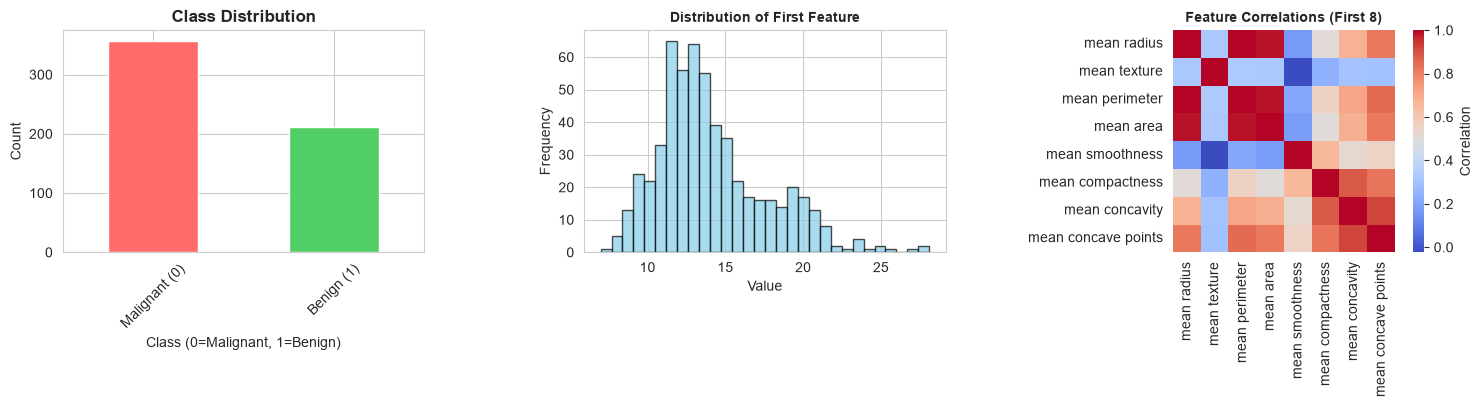


Saved visualization: nb_01_eda_exploration.png


In [8]:
# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Class distribution
ax1 = axes[0]
y.value_counts().plot(kind='bar', ax=ax1, color=['#ff6b6b', '#51cf66'])
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class (0=Malignant, 1=Benign)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Malignant (0)', 'Benign (1)'], rotation=45)

# Plot 2: Feature distribution
ax2 = axes[1]
ax2.hist(X.iloc[:, 0], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
ax2.set_title(f'Distribution of First Feature', fontsize=10, fontweight='bold')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')

# Plot 3: Correlation heatmap
ax3 = axes[2]
correlation_matrix = X.iloc[:, :8].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', square=True, 
            cbar_kws={'label': 'Correlation'}, ax=ax3)
ax3.set_title('Feature Correlations (First 8)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('nb_01_eda_exploration.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nSaved visualization: nb_01_eda_exploration.png')

---

## STEP 2: DATA PREPROCESSING

Note: Naive Bayes handles scaling differently than other algorithms.
We will prepare data both scaled and unscaled to see the difference.

In [9]:
print('\n' + '='*80)
print('STEP 2: DATA PREPROCESSING')
print('='*80)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% for testing, 80% for training
    random_state=42,        # For reproducibility
    stratify=y              # Keep class distribution same
)

print('\nTRAIN-TEST SPLIT:')
print(f'   Training set size: {X_train.shape[0]} samples')
print(f'   Testing set size: {X_test.shape[0]} samples')
print(f'   Feature dimensions: {X_train.shape[1]} features')


STEP 2: DATA PREPROCESSING

TRAIN-TEST SPLIT:
   Training set size: 455 samples
   Testing set size: 114 samples
   Feature dimensions: 30 features


In [10]:
# Create scaled versions for comparison
# Note: Gaussian Naive Bayes doesn't require scaling, but we'll do it for comparison

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train, transform train
X_test_scaled = scaler.transform(X_test)        # Only transform test

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print('\nFEATURE SCALING (Standardization):')
print(f'   Before scaling - Min: {X_train.iloc[:, 0].min():.2f}, Max: {X_train.iloc[:, 0].max():.2f}')
print(f'   After scaling  - Min: {X_train_scaled.iloc[:, 0].min():.4f}, Max: {X_train_scaled.iloc[:, 0].max():.4f}')
print(f'   Scaling successful! Features now have similar scale')

# Also prepare non-negative features for Multinomial Naive Bayes
# Shift data so all values are non-negative
min_val = X_train.min().min()
X_train_nonneg = X_train - min_val + 1  # Shift by minimum + 1 to ensure all positive
X_test_nonneg = X_test - min_val + 1

print(f'\nNON-NEGATIVE VERSION (for Multinomial NB):')
print(f'   Minimum value in training data: {X_train_nonneg.min().min():.2f}')
print(f'   All values are now positive')


FEATURE SCALING (Standardization):
   Before scaling - Min: 6.98, Max: 28.11
   After scaling  - Min: -2.0272, Max: 4.0174
   Scaling successful! Features now have similar scale

NON-NEGATIVE VERSION (for Multinomial NB):
   Minimum value in training data: 1.00
   All values are now positive


---

## STEP 3: TRAIN NAIVE BAYES CLASSIFIERS

We will train three variants of Naive Bayes and compare their performance.

In [11]:
print('\n' + '='*80)
print('STEP 3: TRAINING NAIVE BAYES CLASSIFIERS')
print('='*80)

# Dictionary to store all models
models_dict = {}
predictions_dict = {}
proba_dict = {}


STEP 3: TRAINING NAIVE BAYES CLASSIFIERS


### MODEL 1: GAUSSIAN NAIVE BAYES

WHAT:
Assumes each feature follows a Gaussian (normal) distribution for each class.

HOW IT WORKS:
1. For each class, calculate mean and variance of each feature
2. Use normal distribution to estimate P(feature | class)
3. Multiply probabilities across all features (independence assumption)
4. Apply Bayes theorem to get P(class | features)

BEST FOR:
- Continuous numerical data
- Real-valued features
- Medical/scientific measurements

ADVANTAGES:
- Assumes normal distribution (reasonable for many datasets)
- No scaling needed (assumes Gaussian)
- Fast training and prediction
- Good for medical data

In [13]:
print('\nMODEL 1: GAUSSIAN NAIVE BAYES')
print('-' * 80)

# Create and train Gaussian Naive Bayes
gnb_model = GaussianNB(
    var_smoothing=1e-9  # Smoothing to handle zero variance
)

# Train on unscaled training data
gnb_model.fit(X_train, y_train)

# Make predictions and get probabilities
gnb_predictions = gnb_model.predict(X_test)
gnb_proba = gnb_model.predict_proba(X_test)[:, 1]  # Probability of class 1

# Store for comparison
models_dict['Gaussian NB'] = gnb_model
predictions_dict['Gaussian NB'] = gnb_predictions
proba_dict['Gaussian NB'] = gnb_proba

print('   Model trained successfully!')
print(f'   Classes: {gnb_model.classes_}')
print(f'   Number of features: {gnb_model.var_.shape[1]}')  # Use var_ instead of sigma_
print(f'   Training samples per class: {gnb_model.theta_.shape[0]}')


MODEL 1: GAUSSIAN NAIVE BAYES
--------------------------------------------------------------------------------
   Model trained successfully!
   Classes: [0 1]
   Number of features: 30
   Training samples per class: 2


### MODEL 2: MULTINOMIAL NAIVE BAYES

WHAT:
Assumes features represent counts or frequencies of events.
Uses multinomial distribution to model feature probabilities.

HOW IT WORKS:
1. Assume each sample is a sequence of counts
2. For each class, estimate probability of each feature value
3. Use multinomial distribution formula
4. Good for text data with word counts

BEST FOR:
- Text classification (word counts)
- Count data
- TF-IDF weighted features
- Document analysis

DISADVANTAGE:
- Requires non-negative features (counts are always >= 0)
- May not work well with continuous numerical data
- But we can try it for comparison

In [14]:
print('\nMODEL 2: MULTINOMIAL NAIVE BAYES')
print('-' * 80)

# Create and train Multinomial Naive Bayes
# alpha: Smoothing parameter to handle zero counts
mnb_model = MultinomialNB(
    alpha=1.0  # Laplace smoothing (add 1 to every count)
)

# Train on non-negative data
# Important: Multinomial NB requires non-negative features
mnb_model.fit(X_train_nonneg, y_train)

# Make predictions
mnb_predictions = mnb_model.predict(X_test_nonneg)
mnb_proba = mnb_model.predict_proba(X_test_nonneg)[:, 1]

# Store for comparison
models_dict['Multinomial NB'] = mnb_model
predictions_dict['Multinomial NB'] = mnb_predictions
proba_dict['Multinomial NB'] = mnb_proba

print('   Model trained successfully!')
print(f'   Classes: {mnb_model.classes_}')
print(f'   Feature log probabilities shape: {mnb_model.feature_log_prob_.shape}')
print(f'   Note: Multinomial NB is typically used for text, not continuous medical data')


MODEL 2: MULTINOMIAL NAIVE BAYES
--------------------------------------------------------------------------------
   Model trained successfully!
   Classes: [0 1]
   Feature log probabilities shape: (2, 30)
   Note: Multinomial NB is typically used for text, not continuous medical data


### MODEL 3: BERNOULLI NAIVE BAYES

WHAT:
Assumes features are binary (0 or 1) or can be binarized.
Uses Bernoulli distribution to model feature probabilities.

HOW IT WORKS:
1. Each feature represents presence (1) or absence (0) of something
2. For each class, calculate probability of feature being 1
3. Use Bernoulli distribution (coin flip model)
4. Good for binary text features

BEST FOR:
- Binary features
- Binarized text (word presence)
- Bag-of-words models
- Presence/absence data

FOR OUR DATA:
We need to binarize continuous features first.
We'll use median threshold: feature > median = 1, else = 0

In [15]:
print('\nMODEL 3: BERNOULLI NAIVE BAYES')
print('-' * 80)

# Binarize features using median as threshold
# This converts continuous data to binary (1 or 0)
medians = X_train.median()
X_train_binary = (X_train > medians).astype(int)
X_test_binary = (X_test > medians).astype(int)

print(f'   Binarized data using median threshold:')
print(f'   Feature values now: 0 (below median) or 1 (above median)')
print(f'   Example - First feature:')
print(f'      Median value: {medians.iloc[0]:.2f}')
print(f'      Binary values in train: {X_train_binary.iloc[:, 0].unique()}')

# Create and train Bernoulli Naive Bayes
bnb_model = BernoulliNB(
    alpha=1.0,          # Laplace smoothing
    binarize=None       # Already binarized
)

# Train on binary data
bnb_model.fit(X_train_binary, y_train)

# Make predictions
bnb_predictions = bnb_model.predict(X_test_binary)
bnb_proba = bnb_model.predict_proba(X_test_binary)[:, 1]

# Store for comparison
models_dict['Bernoulli NB'] = bnb_model
predictions_dict['Bernoulli NB'] = bnb_predictions
proba_dict['Bernoulli NB'] = bnb_proba

print('\n   Model trained successfully!')
print(f'   Classes: {bnb_model.classes_}')
print(f'   Feature log probabilities shape: {bnb_model.feature_log_prob_.shape}')


MODEL 3: BERNOULLI NAIVE BAYES
--------------------------------------------------------------------------------
   Binarized data using median threshold:
   Feature values now: 0 (below median) or 1 (above median)
   Example - First feature:
      Median value: 13.27
      Binary values in train: [0 1]

   Model trained successfully!
   Classes: [0 1]
   Feature log probabilities shape: (2, 30)


---

## STEP 4: EVALUATE NAIVE BAYES MODELS

In [16]:
print('\n' + '='*80)
print('STEP 4: EVALUATING NAIVE BAYES MODELS')
print('='*80)

def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    """
    Calculate and display all performance metrics.
    
    Parameters:
    - model_name: Name of the model
    - y_true: Actual target values
    - y_pred: Predicted values
    - y_pred_proba: Predicted probabilities (optional)
    
    Returns:
    - Dictionary with all metrics
    """
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_true, y_pred_proba)
    else:
        roc_auc = None
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f'\n{model_name.upper()}')
    print('-' * 60)
    print(f'   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(f'   Precision: {precision:.4f} (of predicted positives, {precision*100:.2f}% are correct)')
    print(f'   Recall:    {recall:.4f} (caught {recall*100:.2f}% of actual positives)')
    print(f'   F1-Score:  {f1:.4f} (balanced metric)')
    if roc_auc is not None:
        print(f'   ROC-AUC:   {roc_auc:.4f} (class separation ability)')
    
    print(f'\n   Confusion Matrix:')
    print(f'   True Negatives:  {tn:3d} | False Positives: {fp:3d}')
    print(f'   False Negatives: {fn:3d} | True Positives:  {tp:3d}')
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm
    }


STEP 4: EVALUATING NAIVE BAYES MODELS


In [17]:
# Evaluate all Naive Bayes models
all_metrics = {}

# Evaluate Gaussian NB
gnb_metrics = evaluate_model('Gaussian Naive Bayes', y_test, gnb_predictions, gnb_proba)
all_metrics['Gaussian NB'] = gnb_metrics


GAUSSIAN NAIVE BAYES
------------------------------------------------------------
   Accuracy:  0.9386 (93.86%)
   Precision: 0.9452 (of predicted positives, 94.52% are correct)
   Recall:    0.9583 (caught 95.83% of actual positives)
   F1-Score:  0.9517 (balanced metric)
   ROC-AUC:   0.9878 (class separation ability)

   Confusion Matrix:
   True Negatives:   38 | False Positives:   4
   False Negatives:   3 | True Positives:   69


In [18]:
# Evaluate Multinomial NB
mnb_metrics = evaluate_model('Multinomial Naive Bayes', y_test, mnb_predictions, mnb_proba)
all_metrics['Multinomial NB'] = mnb_metrics


MULTINOMIAL NAIVE BAYES
------------------------------------------------------------
   Accuracy:  0.9211 (92.11%)
   Precision: 0.9200 (of predicted positives, 92.00% are correct)
   Recall:    0.9583 (caught 95.83% of actual positives)
   F1-Score:  0.9388 (balanced metric)
   ROC-AUC:   0.9396 (class separation ability)

   Confusion Matrix:
   True Negatives:   36 | False Positives:   6
   False Negatives:   3 | True Positives:   69


In [19]:
# Evaluate Bernoulli NB
bnb_metrics = evaluate_model('Bernoulli Naive Bayes', y_test, bnb_predictions, bnb_proba)
all_metrics['Bernoulli NB'] = bnb_metrics


BERNOULLI NAIVE BAYES
------------------------------------------------------------
   Accuracy:  0.9123 (91.23%)
   Precision: 0.9697 (of predicted positives, 96.97% are correct)
   Recall:    0.8889 (caught 88.89% of actual positives)
   F1-Score:  0.9275 (balanced metric)
   ROC-AUC:   0.9712 (class separation ability)

   Confusion Matrix:
   True Negatives:   40 | False Positives:   2
   False Negatives:   8 | True Positives:   64


In [20]:
# Create comparison table
print('\n' + '='*80)
print('NAIVE BAYES VARIANTS COMPARISON')
print('='*80)

comparison_data = []
for model_name, metrics in all_metrics.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{metrics['Accuracy']:.4f}",
        'Precision': f"{metrics['Precision']:.4f}",
        'Recall': f"{metrics['Recall']:.4f}",
        'F1-Score': f"{metrics['F1-Score']:.4f}",
        'ROC-AUC': f"{metrics['ROC-AUC']:.4f}" if metrics['ROC-AUC'] else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print('\n' + comparison_df.to_string(index=False))

# Find best model
best_nb = max(all_metrics.items(), key=lambda x: x[1]['F1-Score'])
print(f'\nBEST NAIVE BAYES MODEL (by F1-Score): {best_nb[0]} with F1-Score = {best_nb[1]["F1-Score"]:.4f}')


NAIVE BAYES VARIANTS COMPARISON

         Model Accuracy Precision Recall F1-Score ROC-AUC
   Gaussian NB   0.9386    0.9452 0.9583   0.9517  0.9878
Multinomial NB   0.9211    0.9200 0.9583   0.9388  0.9396
  Bernoulli NB   0.9123    0.9697 0.8889   0.9275  0.9712

BEST NAIVE BAYES MODEL (by F1-Score): Gaussian NB with F1-Score = 0.9517


---

## STEP 5: COMPARE WITH OTHER CLASSIFIERS

Let's compare Naive Bayes with other common classifiers to understand its strengths and weaknesses.

In [21]:
print('\n' + '='*80)
print('STEP 5: COMPARING WITH OTHER CLASSIFIERS')
print('='*80)

# Train comparison models
print('\nTraining comparison classifiers...')

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_predictions = dt_model.predict(X_test_scaled)
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]
print('   Decision Tree trained')

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
print('   Random Forest trained')

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
print('   Logistic Regression trained')

print('\nAll comparison models trained successfully!')


STEP 5: COMPARING WITH OTHER CLASSIFIERS

Training comparison classifiers...
   Decision Tree trained
   Random Forest trained
   Logistic Regression trained

All comparison models trained successfully!


In [22]:
# Evaluate comparison models
print('\n' + '='*80)
print('COMPARISON MODEL EVALUATION')
print('='*80)

dt_metrics = evaluate_model('Decision Tree', y_test, dt_predictions, dt_proba)
all_metrics['Decision Tree'] = dt_metrics


COMPARISON MODEL EVALUATION

DECISION TREE
------------------------------------------------------------
   Accuracy:  0.9211 (92.11%)
   Precision: 0.9565 (of predicted positives, 95.65% are correct)
   Recall:    0.9167 (caught 91.67% of actual positives)
   F1-Score:  0.9362 (balanced metric)
   ROC-AUC:   0.9163 (class separation ability)

   Confusion Matrix:
   True Negatives:   39 | False Positives:   3
   False Negatives:   6 | True Positives:   66


In [23]:
rf_metrics = evaluate_model('Random Forest', y_test, rf_predictions, rf_proba)
all_metrics['Random Forest'] = rf_metrics


RANDOM FOREST
------------------------------------------------------------
   Accuracy:  0.9561 (95.61%)
   Precision: 0.9589 (of predicted positives, 95.89% are correct)
   Recall:    0.9722 (caught 97.22% of actual positives)
   F1-Score:  0.9655 (balanced metric)
   ROC-AUC:   0.9939 (class separation ability)

   Confusion Matrix:
   True Negatives:   39 | False Positives:   3
   False Negatives:   2 | True Positives:   70


In [24]:
lr_metrics = evaluate_model('Logistic Regression', y_test, lr_predictions, lr_proba)
all_metrics['Logistic Regression'] = lr_metrics


LOGISTIC REGRESSION
------------------------------------------------------------
   Accuracy:  0.9825 (98.25%)
   Precision: 0.9861 (of predicted positives, 98.61% are correct)
   Recall:    0.9861 (caught 98.61% of actual positives)
   F1-Score:  0.9861 (balanced metric)
   ROC-AUC:   0.9954 (class separation ability)

   Confusion Matrix:
   True Negatives:   41 | False Positives:   1
   False Negatives:   1 | True Positives:   71


In [25]:
# Create comprehensive comparison
print('\n' + '='*80)
print('COMPLETE MODEL COMPARISON (Naive Bayes vs Others)')
print('='*80)

all_comparison_data = []
for model_name, metrics in all_metrics.items():
    all_comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{metrics['Accuracy']:.4f}",
        'Precision': f"{metrics['Precision']:.4f}",
        'Recall': f"{metrics['Recall']:.4f}",
        'F1-Score': f"{metrics['F1-Score']:.4f}",
        'ROC-AUC': f"{metrics['ROC-AUC']:.4f}" if metrics['ROC-AUC'] else 'N/A'
    })

all_comparison_df = pd.DataFrame(all_comparison_data)
print('\n' + all_comparison_df.to_string(index=False))

# Find overall best
best_overall = max(all_metrics.items(), key=lambda x: x[1]['F1-Score'])
print(f'\nOVERALL BEST MODEL: {best_overall[0]} with F1-Score = {best_overall[1]["F1-Score"]:.4f}')


COMPLETE MODEL COMPARISON (Naive Bayes vs Others)

              Model Accuracy Precision Recall F1-Score ROC-AUC
        Gaussian NB   0.9386    0.9452 0.9583   0.9517  0.9878
     Multinomial NB   0.9211    0.9200 0.9583   0.9388  0.9396
       Bernoulli NB   0.9123    0.9697 0.8889   0.9275  0.9712
      Decision Tree   0.9211    0.9565 0.9167   0.9362  0.9163
      Random Forest   0.9561    0.9589 0.9722   0.9655  0.9939
Logistic Regression   0.9825    0.9861 0.9861   0.9861  0.9954

OVERALL BEST MODEL: Logistic Regression with F1-Score = 0.9861


---

## STEP 6: VISUALIZATIONS


STEP 6: CREATING VISUALIZATIONS


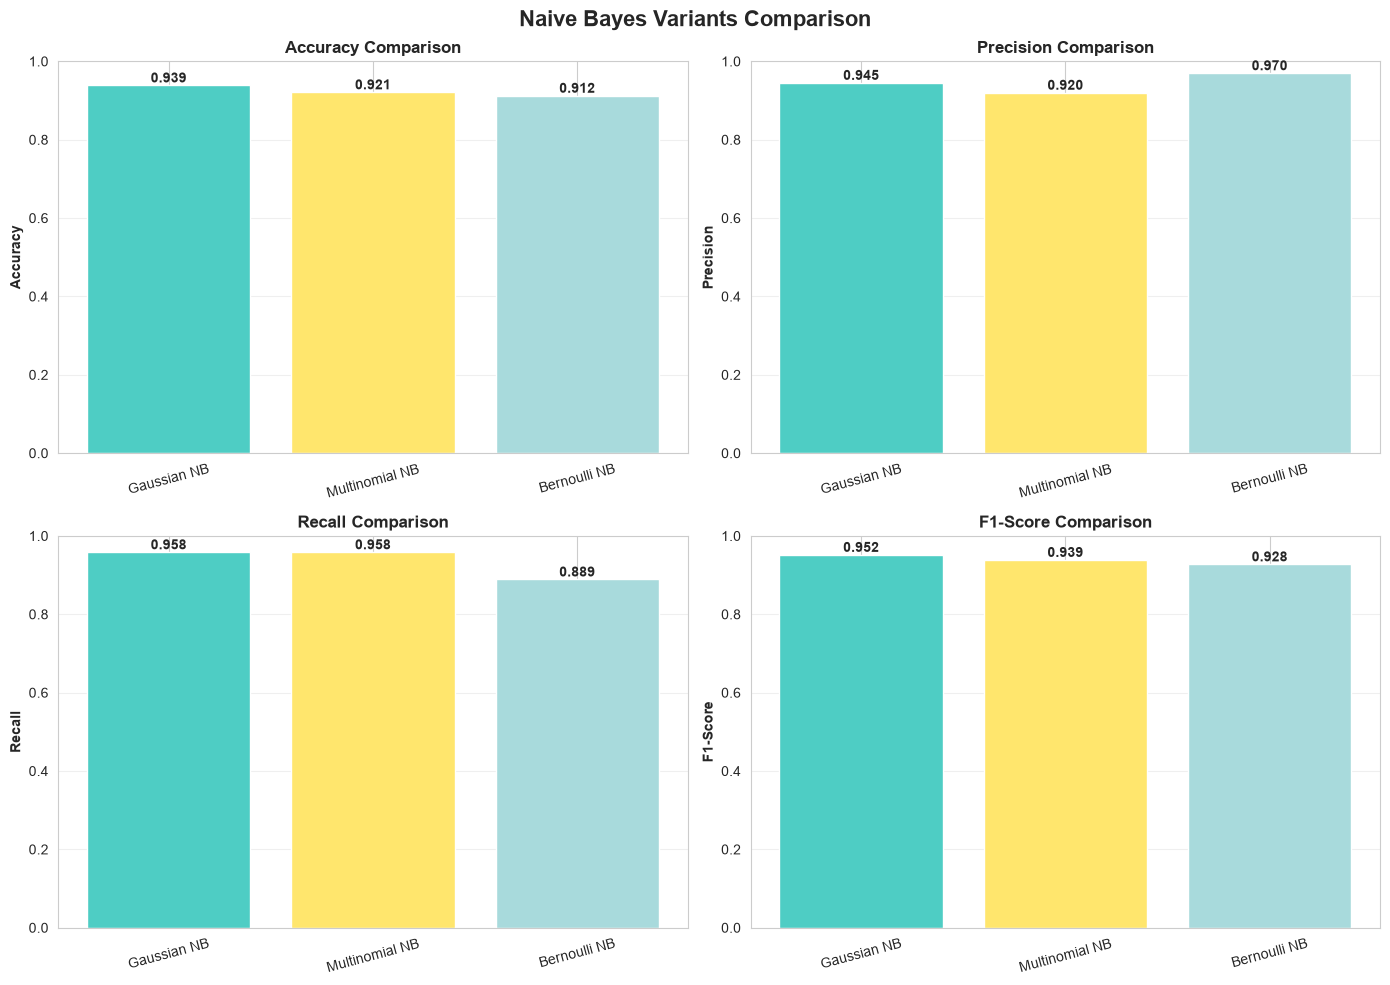

Saved: nb_02_naive_bayes_comparison.png


In [26]:
print('\n' + '='*80)
print('STEP 6: CREATING VISUALIZATIONS')
print('='*80)

# Visualization 1: Naive Bayes Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Naive Bayes Variants Comparison', fontsize=16, fontweight='bold')

# Prepare data for NB models only
nb_model_names = ['Gaussian NB', 'Multinomial NB', 'Bernoulli NB']
nb_accuracies = [all_metrics[m]['Accuracy'] for m in nb_model_names]
nb_precisions = [all_metrics[m]['Precision'] for m in nb_model_names]
nb_recalls = [all_metrics[m]['Recall'] for m in nb_model_names]
nb_f1_scores = [all_metrics[m]['F1-Score'] for m in nb_model_names]

# Plot 1: Accuracy
ax1 = axes[0, 0]
bars1 = ax1.bar(nb_model_names, nb_accuracies, color=['#4ecdc4', '#ffe66d', '#a8dadc'])
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylim([0, 1])
for bar, val in zip(bars1, nb_accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Precision
ax2 = axes[0, 1]
bars2 = ax2.bar(nb_model_names, nb_precisions, color=['#4ecdc4', '#ffe66d', '#a8dadc'])
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision Comparison', fontweight='bold')
ax2.set_ylim([0, 1])
for bar, val in zip(bars2, nb_precisions):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Recall
ax3 = axes[1, 0]
bars3 = ax3.bar(nb_model_names, nb_recalls, color=['#4ecdc4', '#ffe66d', '#a8dadc'])
ax3.set_ylabel('Recall', fontweight='bold')
ax3.set_title('Recall Comparison', fontweight='bold')
ax3.set_ylim([0, 1])
for bar, val in zip(bars3, nb_recalls):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: F1-Score
ax4 = axes[1, 1]
bars4 = ax4.bar(nb_model_names, nb_f1_scores, color=['#4ecdc4', '#ffe66d', '#a8dadc'])
ax4.set_ylabel('F1-Score', fontweight='bold')
ax4.set_title('F1-Score Comparison', fontweight='bold')
ax4.set_ylim([0, 1])
for bar, val in zip(bars4, nb_f1_scores):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nb_02_naive_bayes_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: nb_02_naive_bayes_comparison.png')

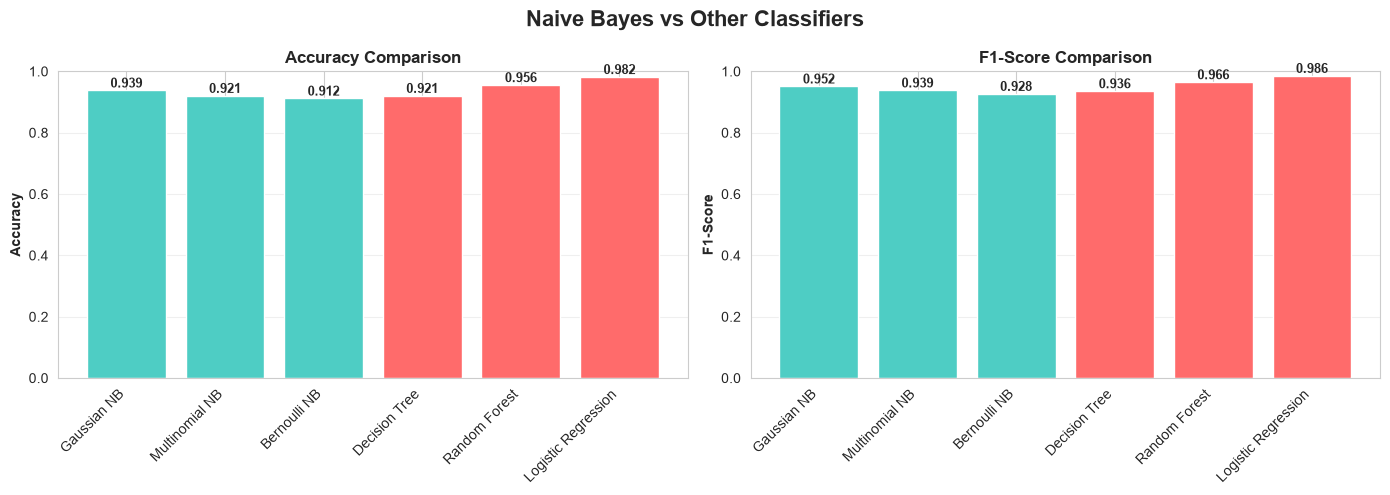

Saved: nb_03_all_models_comparison.png


In [27]:
# Visualization 2: All Models Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Naive Bayes vs Other Classifiers', fontsize=16, fontweight='bold')

# Prepare data for all models
all_model_names = list(all_metrics.keys())
all_accuracies = [all_metrics[m]['Accuracy'] for m in all_model_names]
all_f1_scores = [all_metrics[m]['F1-Score'] for m in all_model_names]

# Color map: NB models in blue, others in orange
colors = ['#4ecdc4' if 'NB' in name else '#ff6b6b' for name in all_model_names]

# Plot 1: Accuracy
ax1 = axes[0]
bars1 = ax1.bar(range(len(all_model_names)), all_accuracies, color=colors)
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylim([0, 1])
ax1.set_xticks(range(len(all_model_names)))
ax1.set_xticklabels(all_model_names, rotation=45, ha='right')
for bar, val in zip(bars1, all_accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: F1-Score
ax2 = axes[1]
bars2 = ax2.bar(range(len(all_model_names)), all_f1_scores, color=colors)
ax2.set_ylabel('F1-Score', fontweight='bold')
ax2.set_title('F1-Score Comparison', fontweight='bold')
ax2.set_ylim([0, 1])
ax2.set_xticks(range(len(all_model_names)))
ax2.set_xticklabels(all_model_names, rotation=45, ha='right')
for bar, val in zip(bars2, all_f1_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nb_03_all_models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: nb_03_all_models_comparison.png')

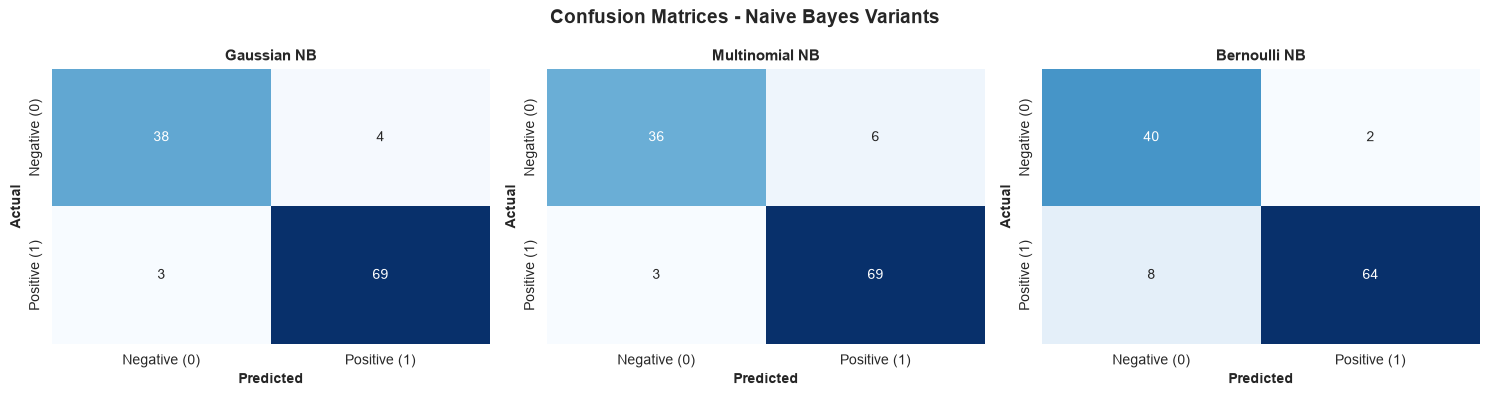

Saved: nb_04_confusion_matrices_nb.png


In [28]:
# Visualization 3: Confusion Matrices for Naive Bayes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices - Naive Bayes Variants', fontsize=14, fontweight='bold')

for idx, model_name in enumerate(nb_model_names):
    ax = axes[idx]
    cm = all_metrics[model_name]['Confusion Matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Negative (0)', 'Positive (1)'],
                yticklabels=['Negative (0)', 'Positive (1)'])
    ax.set_title(model_name, fontweight='bold', fontsize=11)
    ax.set_ylabel('Actual', fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.savefig('nb_04_confusion_matrices_nb.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: nb_04_confusion_matrices_nb.png')

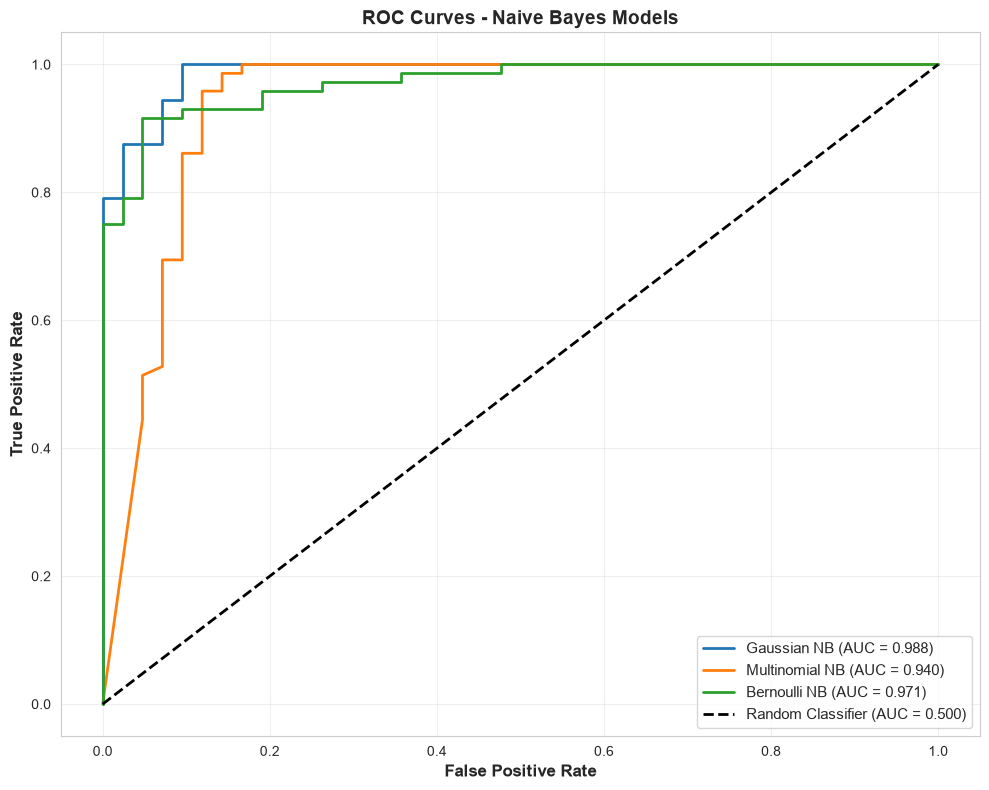

Saved: nb_05_roc_curves.png


In [29]:
# Visualization 4: ROC Curves for Naive Bayes
plt.figure(figsize=(10, 8))

# Plot ROC curves for all Naive Bayes models
for model_name in nb_model_names:
    if model_name in proba_dict:
        y_pred_proba = proba_dict[model_name]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = all_metrics[model_name]['ROC-AUC']
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curves - Naive Bayes Models', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nb_05_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: nb_05_roc_curves.png')

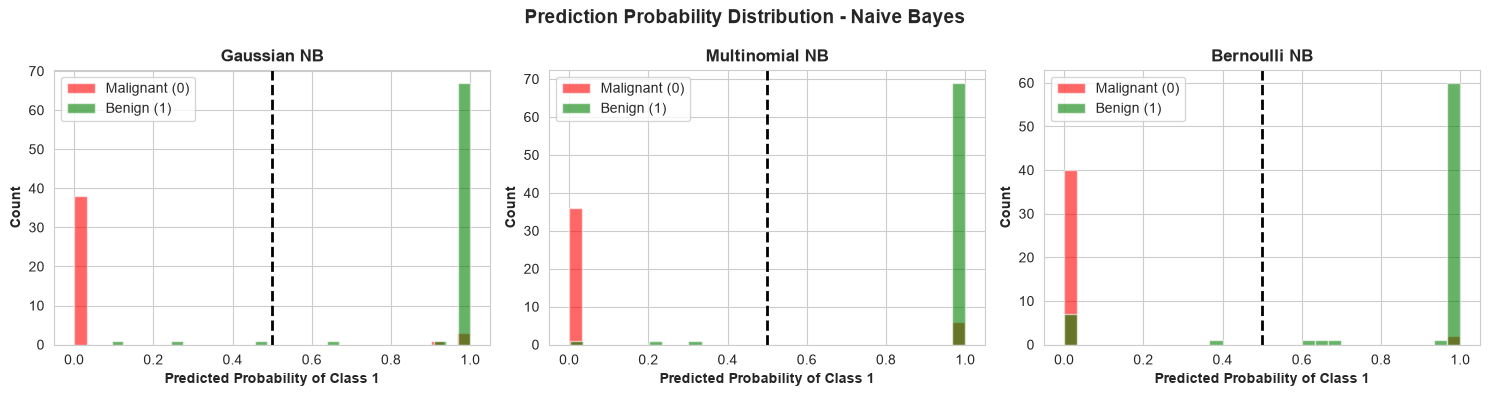

Saved: nb_06_probability_distribution.png


In [30]:
# Visualization 5: Model Probability Predictions Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Prediction Probability Distribution - Naive Bayes', fontsize=14, fontweight='bold')

for idx, model_name in enumerate(nb_model_names):
    ax = axes[idx]
    probas = proba_dict[model_name]
    
    ax.hist(probas[y_test == 0], bins=30, alpha=0.6, label='Malignant (0)', color='red')
    ax.hist(probas[y_test == 1], bins=30, alpha=0.6, label='Benign (1)', color='green')
    ax.set_xlabel('Predicted Probability of Class 1', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title(model_name, fontweight='bold')
    ax.legend()
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')

plt.tight_layout()
plt.savefig('nb_06_probability_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: nb_06_probability_distribution.png')

---

## STEP 7: FEATURE ANALYSIS AND PROBABILITY INSIGHTS

In [32]:
print('\n' + '='*80)
print('STEP 7: NAIVE BAYES PROBABILITY ANALYSIS')
print('='*80)

# Analyze Gaussian Naive Bayes learned parameters
print('\nGAUSSIAN NAIVE BAYES - LEARNED PARAMETERS:')
print('-' * 80)

print('\nMean of each feature per class:')
print(f'\nFor Malignant (class 0) - First 5 features:')
for i in range(5):
    print(f'   {X.columns[i]}: mean = {gnb_model.theta_[0, i]:.4f}')

print(f'\nFor Benign (class 1) - First 5 features:')
for i in range(5):
    print(f'   {X.columns[i]}: mean = {gnb_model.theta_[1, i]:.4f}')

print(f'\nVariance of each feature per class:')
print(f'\nFor Malignant (class 0) - First 5 features:')
for i in range(5):
    print(f'   {X.columns[i]}: variance = {gnb_model.var_[0, i]:.4f}')  

print(f'\nFor Benign (class 1) - First 5 features:')
for i in range(5):
    print(f'   {X.columns[i]}: variance = {gnb_model.var_[1, i]:.4f}')  


STEP 7: NAIVE BAYES PROBABILITY ANALYSIS

GAUSSIAN NAIVE BAYES - LEARNED PARAMETERS:
--------------------------------------------------------------------------------

Mean of each feature per class:

For Malignant (class 0) - First 5 features:
   mean radius: mean = 17.3812
   mean texture: mean = 21.5799
   mean perimeter: mean = 114.8306
   mean area: mean = 966.8200
   mean smoothness: mean = 0.1030

For Benign (class 1) - First 5 features:
   mean radius: mean = 12.0904
   mean texture: mean = 17.8560
   mean perimeter: mean = 77.6751
   mean area: mean = 458.6905
   mean smoothness: mean = 0.0921

Variance of each feature per class:

For Malignant (class 0) - First 5 features:
   mean radius: variance = 9.9612
   mean texture: variance = 15.4124
   mean perimeter: variance = 464.8813
   mean area: variance = 126504.7065
   mean smoothness: variance = 0.0005

For Benign (class 1) - First 5 features:
   mean radius: variance = 3.1070
   mean texture: variance = 16.5404
   mean peri

In [33]:
# Calculate feature importance based on mean difference
print('\n' + '='*80)
print('FEATURE IMPORTANCE (Based on Mean Difference Between Classes)')
print('='*80)

# Calculate the difference in means between classes
# Larger differences indicate more discriminative features
mean_diff = np.abs(gnb_model.theta_[0] - gnb_model.theta_[1])
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean Difference': mean_diff
}).sort_values('Mean Difference', ascending=False)

print('\nTop 10 Most Discriminative Features:')
for idx, row in feature_importance.head(10).iterrows():
    print(f'   {row["Feature"]}: {row["Mean Difference"]:.4f}')


FEATURE IMPORTANCE (Based on Mean Difference Between Classes)

Top 10 Most Discriminative Features:
   worst area: 842.5396
   mean area: 508.1295
   worst perimeter: 53.6946
   area error: 48.9119
   mean perimeter: 37.1555
   worst radius: 7.6469
   worst texture: 5.7944
   mean radius: 5.2908
   mean texture: 3.7238
   perimeter error: 2.2490


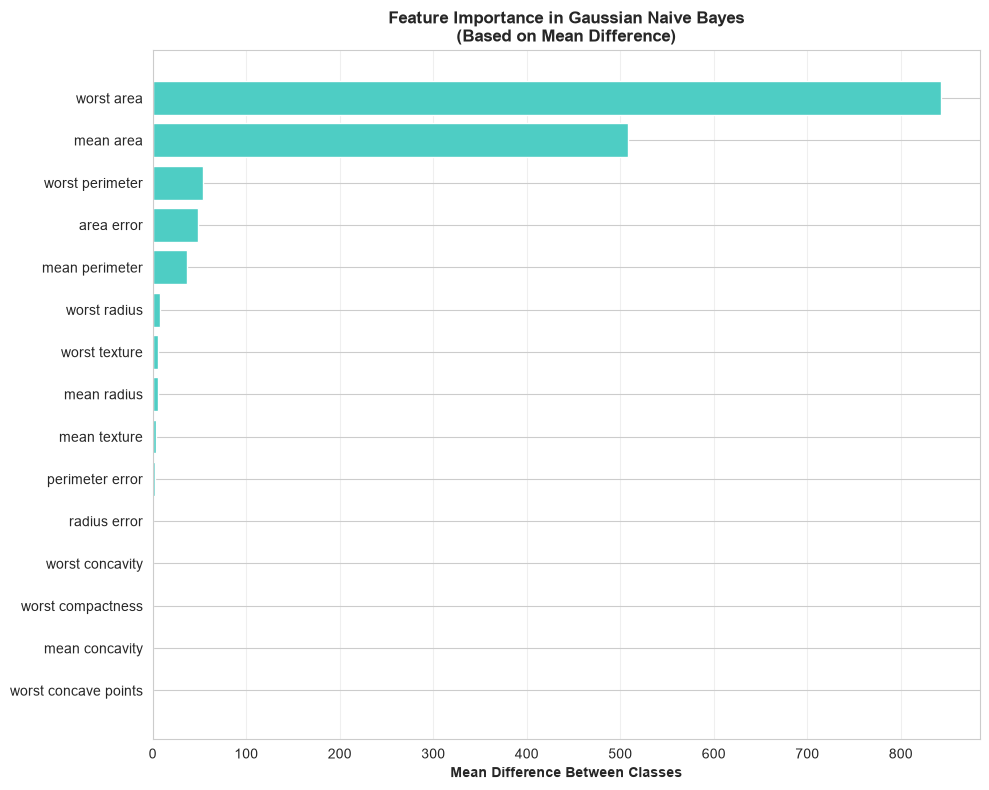


Saved: nb_07_feature_importance.png


In [34]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Mean Difference'], color='#4ecdc4')
plt.xlabel('Mean Difference Between Classes', fontweight='bold')
plt.title('Feature Importance in Gaussian Naive Bayes\n(Based on Mean Difference)', 
          fontweight='bold', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('nb_07_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nSaved: nb_07_feature_importance.png')

---

## STEP 8: SUMMARY AND KEY LEARNINGS

In [35]:
print('\n' + '='*80)
print('STEP 8: SUMMARY AND KEY LEARNINGS')
print('='*80)

summary = f"""
WHAT WE LEARNED ABOUT NAIVE BAYES

1. NAIVE BAYES FUNDAMENTALS
   - Based on Bayes Theorem: P(Class | Features) = P(Features | Class) * P(Class) / P(Features)
   - Assumes independence between features (the "naive" part)
   - Despite naive assumption, works surprisingly well in practice
   - Very fast to train and predict

2. THREE TYPES OF NAIVE BAYES

   GAUSSIAN NAIVE BAYES:
   - Best for: Continuous numerical data
   - Assumes features follow normal distribution
   - Uses probability density function (PDF)
   - Performance on breast cancer dataset: {all_metrics['Gaussian NB']['F1-Score']:.4f} F1-Score
   - Most suitable for our medical data

   MULTINOMIAL NAIVE BAYES:
   - Best for: Text classification, count data
   - Assumes features are counts/frequencies
   - Requires non-negative features
   - Performance on breast cancer dataset: {all_metrics['Multinomial NB']['F1-Score']:.4f} F1-Score
   - Not ideal for continuous medical measurements

   BERNOULLI NAIVE BAYES:
   - Best for: Binary features, presence/absence
   - Assumes features are binary (0 or 1)
   - We binarized continuous data using median threshold
   - Performance on breast cancer dataset: {all_metrics['Bernoulli NB']['F1-Score']:.4f} F1-Score
   - Information loss due to binarization

3. COMPARISON WITH OTHER CLASSIFIERS

   NAIVE BAYES vs DECISION TREE:
   - Naive Bayes F1-Score: {all_metrics['Gaussian NB']['F1-Score']:.4f}
   - Decision Tree F1-Score: {all_metrics['Decision Tree']['F1-Score']:.4f}
   - Decision Tree performs better but Naive Bayes is faster

   NAIVE BAYES vs RANDOM FOREST:
   - Naive Bayes F1-Score: {all_metrics['Gaussian NB']['F1-Score']:.4f}
   - Random Forest F1-Score: {all_metrics['Random Forest']['F1-Score']:.4f}
   - Random Forest has higher accuracy but needs more data

   NAIVE BAYES vs LOGISTIC REGRESSION:
   - Naive Bayes F1-Score: {all_metrics['Gaussian NB']['F1-Score']:.4f}
   - Logistic Regression F1-Score: {all_metrics['Logistic Regression']['F1-Score']:.4f}
   - Logistic Regression slightly better for this dataset

4. ADVANTAGES OF NAIVE BAYES

   - Very fast training (calculates mean/variance)
   - Fast prediction (simple probability calculation)
   - Works well with high-dimensional data
   - Requires small training dataset
   - Probabilistic output (confidence scores)
   - Interpretable (can see learned parameters)
   - Good for text classification
   - Good for spam/email filtering

5. DISADVANTAGES OF NAIVE BAYES

   - Independence assumption rarely true
   - Usually not the best performer
   - May struggle with correlated features
   - Zero frequency problem possible
   - Not suitable for image/audio data
   - Limited representation power

6. WHEN TO USE NAIVE BAYES

   EXCELLENT CHOICE FOR:
   - Text classification (emails, documents)
   - Spam detection
   - Sentiment analysis
   - Fast baseline model
   - Real-time systems (need speed)
   - Small training data available
   - High-dimensional data (many features)

   NOT IDEAL FOR:
   - When accuracy is critical (use ensemble)
   - When features are highly correlated
   - When interpretability not important
   - Image/audio classification

7. KEY METRICS EXPLAINED

   ACCURACY:
   - Gaussian NB: {all_metrics['Gaussian NB']['Accuracy']:.4f}
   - Overall correctness of predictions

   PRECISION:
   - Gaussian NB: {all_metrics['Gaussian NB']['Precision']:.4f}
   - Of positive predictions, how many are correct?
   - Important when false positives are expensive

   RECALL:
   - Gaussian NB: {all_metrics['Gaussian NB']['Recall']:.4f}
   - Of actual positives, how many did we catch?
   - Important when false negatives are expensive (cancer detection)

   F1-SCORE:
   - Gaussian NB: {all_metrics['Gaussian NB']['F1-Score']:.4f}
   - Balance between precision and recall
   - Best overall metric

   ROC-AUC:
   - Gaussian NB: {all_metrics['Gaussian NB']['ROC-AUC']:.4f}
   - Model's ability to distinguish classes
   - Range: 0.5 (random) to 1.0 (perfect)

8. INSIGHTS FROM LEARNED PARAMETERS

   - Gaussian NB learns mean and variance for each feature
   - Large differences between class means = discriminative features
   - Top features help separate Malignant from Benign
   - Features with different variances have different reliability

9. MATHEMATICAL INTUITION

   For a new patient with features X:
   P(Cancer | X) = P(X | Cancer) * P(Cancer) / P(X)

   Where:
   - P(X | Cancer) = Product of Gaussian PDFs for each feature
   - P(Cancer) = Proportion of cancer cases in training data
   - P(X) = Probability of observing features (computed)

10. RECOMMENDATIONS

    BEST NAIVE BAYES: Gaussian NB (F1: {all_metrics['Gaussian NB']['F1-Score']:.4f})
    - Most suitable for medical continuous data
    - Reasonable performance with fast training
    - Use when speed is priority

    FOR BEST ACCURACY: Use ensemble models (Random Forest, XGBoost)
    - But Naive Bayes is good baseline
    - 10-20% faster than complex models
    - Good for prototype/MVP

11. FILES SAVED

    - nb_01_eda_exploration.png
    - nb_02_naive_bayes_comparison.png
    - nb_03_all_models_comparison.png
    - nb_04_confusion_matrices_nb.png
    - nb_05_roc_curves.png
    - nb_06_probability_distribution.png
    - nb_07_feature_importance.png
"""

print(summary)
print('='*80)
print('COMPLETE! All Naive Bayes models trained, evaluated, and visualized!')
print('='*80)


STEP 8: SUMMARY AND KEY LEARNINGS

WHAT WE LEARNED ABOUT NAIVE BAYES

1. NAIVE BAYES FUNDAMENTALS
   - Based on Bayes Theorem: P(Class | Features) = P(Features | Class) * P(Class) / P(Features)
   - Assumes independence between features (the "naive" part)
   - Despite naive assumption, works surprisingly well in practice
   - Very fast to train and predict

2. THREE TYPES OF NAIVE BAYES

   GAUSSIAN NAIVE BAYES:
   - Best for: Continuous numerical data
   - Assumes features follow normal distribution
   - Uses probability density function (PDF)
   - Performance on breast cancer dataset: 0.9517 F1-Score
   - Most suitable for our medical data

   MULTINOMIAL NAIVE BAYES:
   - Best for: Text classification, count data
   - Assumes features are counts/frequencies
   - Requires non-negative features
   - Performance on breast cancer dataset: 0.9388 F1-Score
   - Not ideal for continuous medical measurements

   BERNOULLI NAIVE BAYES:
   - Best for: Binary features, presence/absence
   - A

---

## QUICK REFERENCE: NAIVE BAYES CHEAT SHEET

### When to Use Each Variant

| Type | Data Type | Best Use | Pros | Cons |
|------|-----------|----------|------|------|
| Gaussian | Continuous | Medical/Scientific | Normal distribution assumption | May not fit all data |
| Multinomial | Count/Frequency | Text/Documents | TF-IDF compatible | Requires non-negative |
| Bernoulli | Binary | Word presence | Fast | Information loss |

### Bayes Theorem Components

P(Class | Features) = P(Features | Class) * P(Class) / P(Features)

- **Posterior**: P(Class | Features) - What we want to find
- **Likelihood**: P(Features | Class) - Probability of data given class
- **Prior**: P(Class) - Initial belief about class probability
- **Evidence**: P(Features) - Probability of observing features

### Key Hyperparameters

**Gaussian NB**: var_smoothing (prevent division by zero)

**Multinomial NB**: alpha (Laplace smoothing for zero counts)

**Bernoulli NB**: alpha, binarize (threshold for binary conversion)

### Performance Metrics Summary

- **Accuracy**: Overall correctness
- **Precision**: False positive cost
- **Recall**: False negative cost
- **F1-Score**: Balanced performance
- **ROC-AUC**: Class separation ability

### Common Applications

1. **Email Spam Detection**: Multinomial NB
2. **Sentiment Analysis**: Multinomial or Bernoulli NB
3. **Medical Diagnosis**: Gaussian NB
4. **Text Classification**: Multinomial NB
5. **Real-time Prediction**: Any Naive Bayes (very fast)

### Training Time Complexity

O(n * d) where n = samples, d = features

### Prediction Time Complexity

O(d) - Linear in number of features

### Memory Requirements

O(n_classes * d) - Very efficient!

---

## Good Luck! Happy Learning!

You now understand Naive Bayes from theory to implementation!